In [1]:
import pandas as pd
import numpy as np
import astropy 
from astropy.table import Table, hstack
from astropy.io import fits
import matplotlib.pyplot as plt
import requests
import os
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm


from utils import plot_spectrum
from Data_handler import get_spectrum, prepare_agn_data
from utils import load_config
from train_classifier import train_model

%load_ext autoreload
%autoreload 2


In [6]:
num_type1 = (df["agn_type"] == 1).sum()
num_type2 = (df["agn_type"] == 2).sum()
alpha_type2 = num_type1 / (num_type1 + num_type2)
print(alpha_type2)

0.23970557957586988


Using full data
Epoch 1 | Val F1: 0.4965 | Alpha: 0.00
Epoch 2 | Val F1: 0.8544 | Alpha: 0.17
Epoch 3 | Val F1: 0.9294 | Alpha: 0.32
Epoch 4 | Val F1: 0.9126 | Alpha: 0.46
Epoch 5 | Val F1: 0.9545 | Alpha: 0.58
Epoch 6 | Val F1: 0.9683 | Alpha: 0.68
Epoch 7 | Val F1: 0.9760 | Alpha: 0.76
Epoch 8 | Val F1: 0.9645 | Alpha: 0.82
Epoch 9 | Val F1: 0.9640 | Alpha: 0.87
Epoch 10 | Val F1: 0.9452 | Alpha: 0.91
Epoch 11 | Val F1: 0.9680 | Alpha: 0.93
Epoch 12 | Val F1: 0.9716 | Alpha: 0.95
Epoch 13 | Val F1: 0.9745 | Alpha: 0.96
Epoch 14 | Val F1: 0.9790 | Alpha: 0.97
Epoch 15 | Val F1: 0.9720 | Alpha: 0.98
Epoch 16 | Val F1: 0.9745 | Alpha: 0.99
Epoch 17 | Val F1: 0.9754 | Alpha: 0.99
Epoch 18 | Val F1: 0.9765 | Alpha: 0.99
Epoch 19 | Val F1: 0.9766 | Alpha: 1.00
Epoch 20 | Val F1: 0.9690 | Alpha: 1.00
Epoch 21 | Val F1: 0.9709 | Alpha: 1.00
Epoch 22 | Val F1: 0.9779 | Alpha: 1.00
Epoch 23 | Val F1: 0.9714 | Alpha: 1.00
Epoch 24 | Val F1: 0.9774 | Alpha: 1.00
Epoch 25 | Val F1: 0.9829 | Alpha

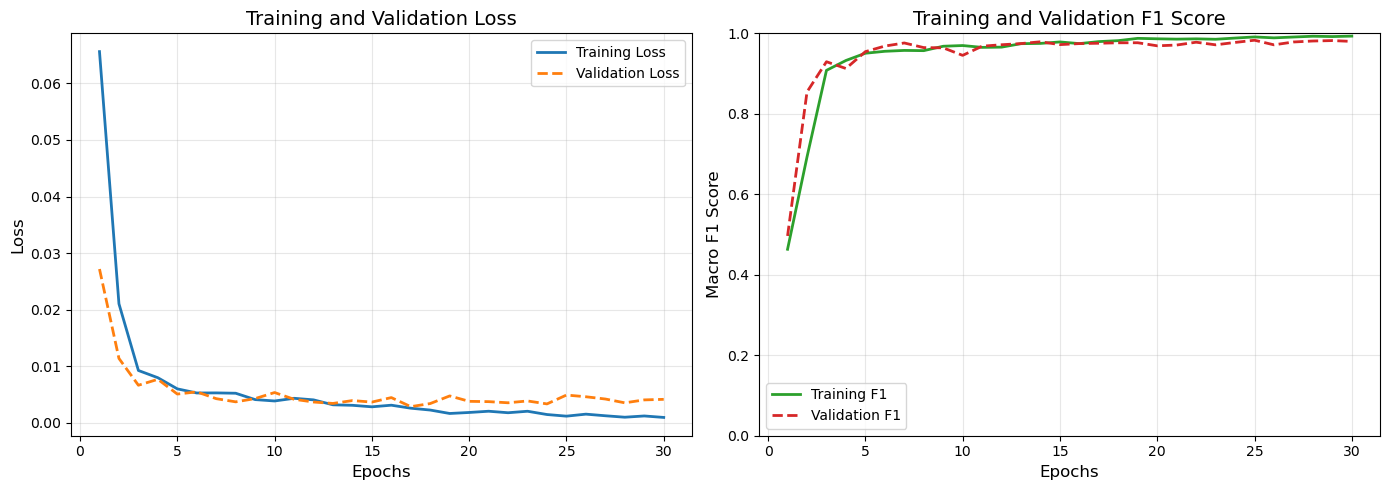


=== Evaluating on Test Data ===


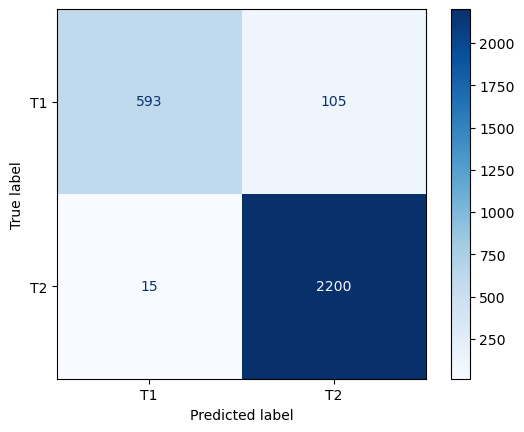

DEBUG: Raw weights shape: torch.Size([1, 128, 128])
DEBUG: Maximum attention localized at exactly: 6541.2 Å
DEBUG: Raw weights shape: torch.Size([1, 128, 128])
DEBUG: Maximum attention localized at exactly: 6111.4 Å


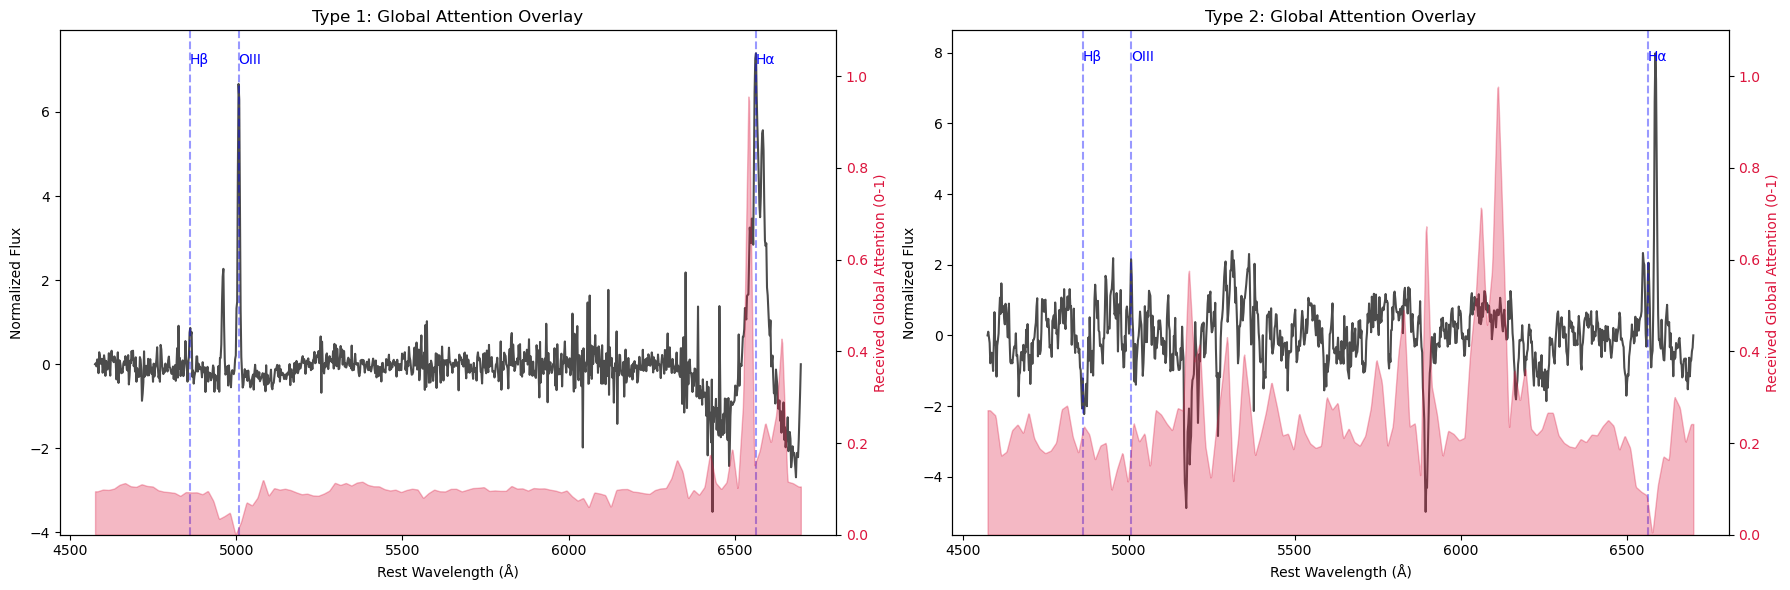

Using device: mps
Loaded trained model.
Collected 50 correct Type 1 CAMs
Collected 50 correct Type 2 CAMs
Saved subplot Grad-CAM figure to: /Users/amir/Documents/Deep learning/cl-agn classifier/models/signed_gradcam_true_class_subplots.png


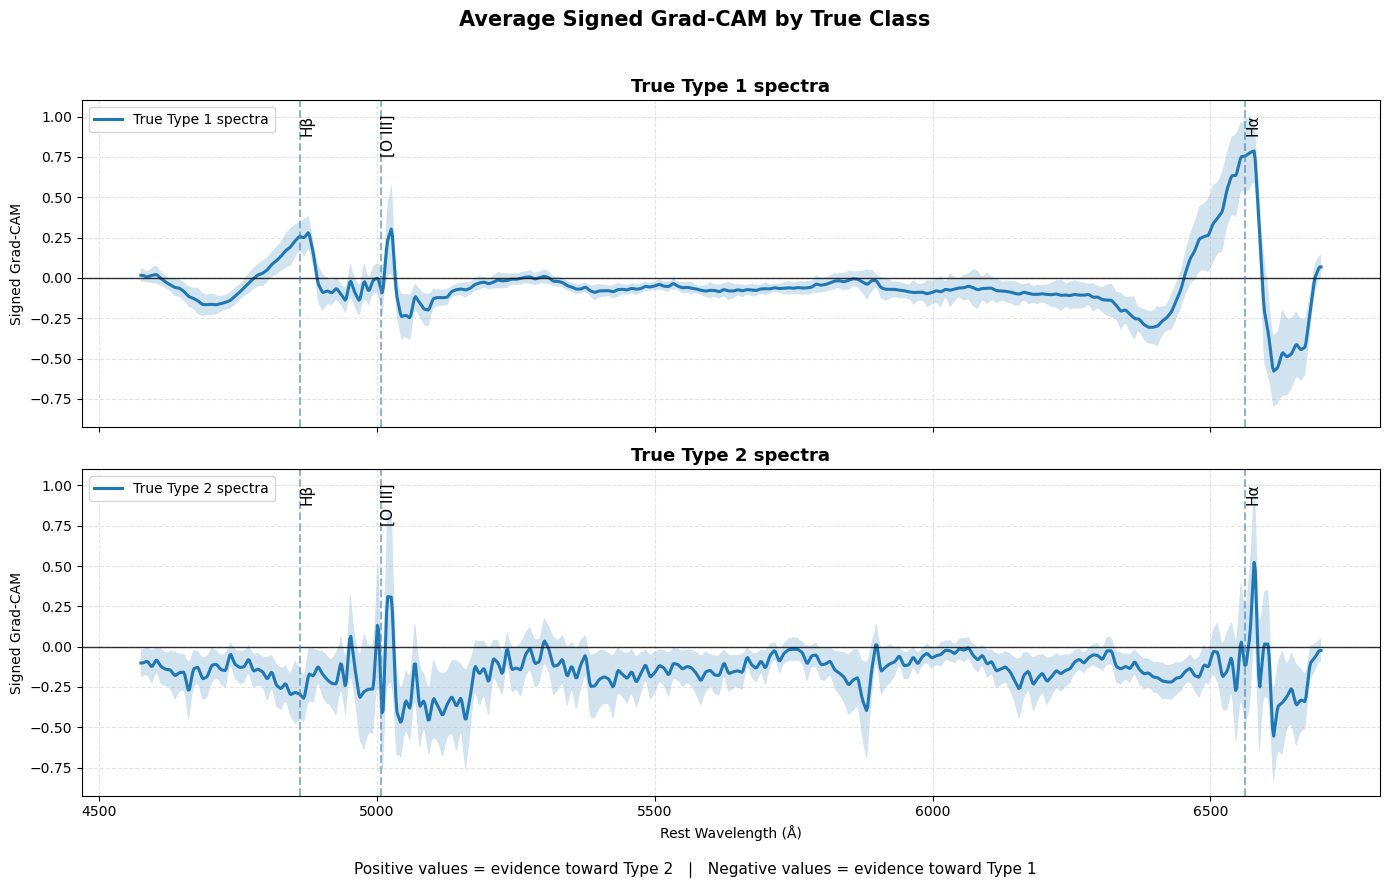

In [2]:
train_model()

In [3]:
df = pd.read_parquet('../data/processed_agn_new.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19428 entries, 0 to 22859
Columns: 1029 entries, filename to 6699.0
dtypes: float32(1026), int64(1), object(2)
memory usage: 76.6+ MB


In [12]:
df[df['obj_id'] == 1874764682066159616]

,filename,obj_id,agn_type,z,snr,3000.0,3001.807081807082,3003.6141636141638,3005.421245421245,3007.228327228327,...,10383.736263736264,10385.543345543345,10387.350427350428,10389.15750915751,10390.964590964591,10392.771672771672,10394.578754578753,10396.385836385836,10398.192918192919,10400.0
10064,spec-1665-52976-0514.fits,1874764682066159616,2,0.016749,96.935776,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
df['agn_type'].value_counts()

agn_type
2    16994
1     4813
Name: count, dtype: int64

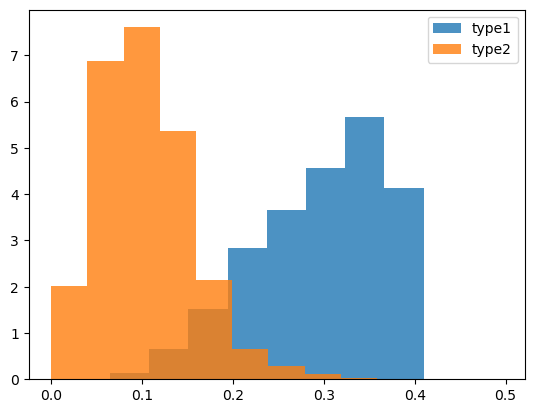

In [4]:
z1 = df.loc[df['agn_type'] == 1, 'z']
z2 = df.loc[df['agn_type'] == 2, 'z']


plt.hist(z1,alpha = 0.8,density=True,label = 'type1')
plt.hist(z2,alpha = 0.8,density=True,label = 'type2')
plt.legend()
plt.show()

In [ ]:
# 1. Identify EXACTLY what is in X
all_cols = df.columns.tolist()
# Explicitly list EVERY non-flux column you've ever mentioned
forbidden_cols = ['filename', 'agn_type', 'z', 'snr', 'obj_id', 'index', 'Unnamed: 0']
flux_cols = [c for c in all_cols if c not in forbidden_cols]

X_test = df[flux_cols].values
print(f"DEBUG: X has {X_test.shape[1]} columns.")

# 2. THE ULTIMATE SANITY CHECK
if X_test.shape[1] != 4096:
    print(f"CRITICAL ERROR: X has {X_test.shape[1]} columns. You are leaking metadata!")

In [ ]:
df['agn_type']

In [ ]:
z1 = df.loc[df['agn_type'] == 1, 'z']
z2 = df.loc[df['agn_type'] == 2,'z']

In [ ]:
df_filtered = df[(df['z'] > 0.15) & (df['z'] < 0.22)]


df_filtered['agn_type'].value_counts()


In [ ]:
import pandas as pd
import numpy as np

# Load your 4096-column processed data
df = pd.read_parquet('../data/processed_agn_catalog.parquet')
meta_cols = ['filename', 'agn_type', 'z', 'snr', 'obj_id']
flux_cols = [c for c in df.columns if c not in meta_cols]
wavelengths = np.array(flux_cols).astype(float)

# Identify which pixels are NEVER zero across the whole dataset
# (We check for != 0.0 across all rows)
is_never_zero = (df[flux_cols] != 0.0).all(axis=0)

# The 'Safe Box' is the range where this mask is True
safe_wavelengths = wavelengths[is_never_zero]
blue_limit = safe_wavelengths.min()
red_limit = safe_wavelengths.max()

print(f"--- Safe Overlap Analysis ---")
print(f"Safe Blue Limit: {blue_limit:.1f} Å")
print(f"Safe Red Limit:  {red_limit:.1f} Å")
print(f"Total valid range: {red_limit - blue_limit:.1f} Å")

In [ ]:
meta_cols = ['filename', 'agn_type', 'z', 'snr', 'obj_id']
# Everything else is a wavelength (as a string)
flux_cols = [c for c in df.columns if c not in meta_cols]
wavelengths = np.array(flux_cols).astype(float)

# --- 3. Detect the "Zero Cliff" ---
# Convert to numpy matrix for speed
flux_matrix = df[flux_cols].values

# Find the index of the last non-zero value for every row
# This tells us where the real data ends and padding begins
def find_last(row):
    nonzero = np.where(row != 0.0)[0]
    return nonzero[-1] if len(nonzero) > 0 else 0

last_indices = np.apply_along_axis(find_last, 1, flux_matrix)

# Map indices back to actual wavelengths
df['padding_start_wave'] = wavelengths[last_indices]

# --- 4. Plot the Distribution ---
plt.figure(figsize=(10, 6))

# Filter by Type 1 and Type 2
t1 = df[df['agn_type'] == 1]['padding_start_wave']
t2 = df[df['agn_type'] == 2]['padding_start_wave']

plt.hist(t1, bins=50, alpha=0.5, label='Type 1', color='#3498db')
plt.hist(t2, bins=50, alpha=0.5, label='Type 2', color='#e67e22')

plt.axvline(t1.min(), color='red', linestyle='--', label=f'Safe Cutoff: {t1.min():.0f}Å')

plt.title('Distribution of Spectral End-Points (Where Zeros Begin)', fontsize=14)
plt.xlabel('Rest-Frame Wavelength (Å)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- 5. Print the Evidence ---
print("\n=== Padding Analysis ===")
print(f"Type 1 (Minority) usually ends at: {t1.mean():.1f} Å")
print(f"Type 2 (Majority) usually ends at: {t2.mean():.1f} Å")
print(f"\nTo stop the 'cheating', you should crop the grid to: {t1.min():.0f} Å")

In [ ]:
df['z'].describe()